In [339]:
import os
import json
import pandas as pd
from tqdm.notebook import tqdm 

folder_path = '/Users/lukepiper/Downloads/t20s_json'
files = [f for f in os.listdir(folder_path) if f.endswith('.json')]

#extract and order matches by date
matches = []

for file in tqdm(files):

    path = os.path.join(folder_path, file)

    with open(path) as f:
        data = json.load(f)

    date = data['info']['dates'][0]

    matches.append({
        "date": datetime.strptime(date, "%Y-%m-%d"),
        "data": data
    })

# sort matches by date
matches = sorted(matches, key=lambda x: x["date"])

#split test vs train dataset 
train_size = int(len(matches) * 0.8)

train_matches = matches[:train_size]
test_matches = matches[train_size:]

print("Train matches:", len(train_matches))
print("Test matches:", len(test_matches))

  0%|          | 0/5053 [00:00<?, ?it/s]

Train matches: 4042
Test matches: 1011


In [527]:
from collections import defaultdict

# Each player will have a list of runs per delivery
player_deliveries = defaultdict(list)

for match in test_matches:
    data = match['data']
    
    for inning in data['innings']:
        overs = inning.get('overs', [])
        for over in overs:
            deliveries = over.get('deliveries', [])
            for delivery in deliveries:
                batsman = delivery['batter']
                runs = delivery['runs']['batter']
                player_deliveries[batsman].append(runs)

In [529]:
import numpy as np

player_prob_dist = {}

for player, deliveries in player_deliveries.items():
    counts = np.bincount(deliveries)  # counts of 0,1,2,3,4,5,6 (if present)
    probs = counts / counts.sum()      # normalize to probabilities
    player_prob_dist[player] = probs

# Example: probability distribution for first player
example_player = list(player_prob_dist.keys())[0]
print("Delivery-level probabilities for", example_player)
print(player_prob_dist[example_player])
    

Delivery-level probabilities for SA Wittmann
[0.56399132 0.2494577  0.04772234 0.         0.11496746 0.
 0.02386117]


In [531]:
0.56399132+  0.2494577 + 0.04772234 +         0.11496746 +0.02386117

0.99999999

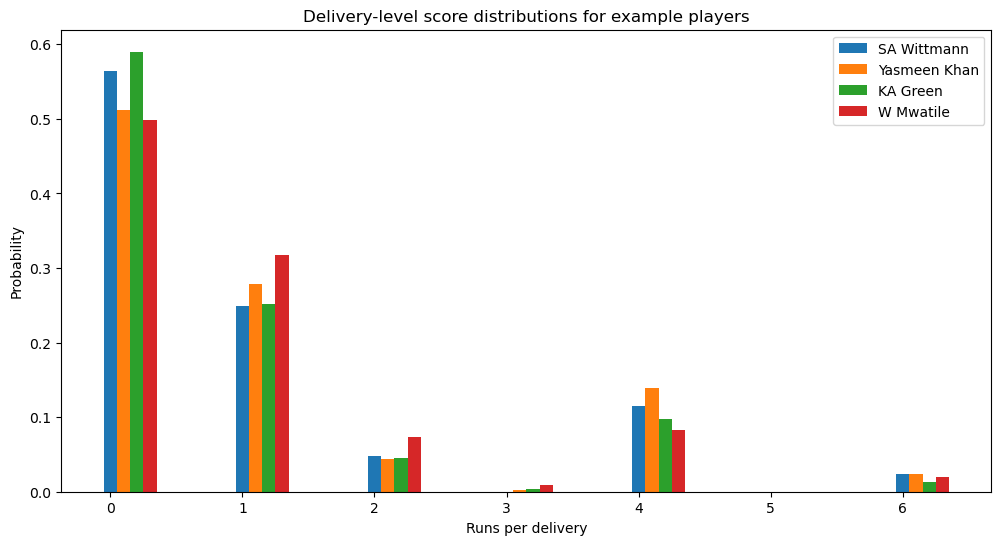

In [533]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a few example players
example_players = list(player_prob_dist.keys())[:4]  # first 4 players

scores = np.arange(7)  # possible delivery scores: 0,1,2,3,4,5,6

plt.figure(figsize=(12, 6))

for player in example_players:
    probs = player_prob_dist[player]
    plt.bar(scores + 0.1*example_players.index(player), probs, width=0.1, label=player)

plt.xticks(scores)
plt.xlabel("Runs per delivery")
plt.ylabel("Probability")
plt.title("Delivery-level score distributions for example players")
plt.legend()
plt.show()

In [535]:
# Example: baseline P(score) for 0-6
baseline_dist = np.array([0.4, 0.3, 0.1, 0.05, 0.1, 0.0, 0.05])
baseline_dist /= baseline_dist.sum()  # normalize

def get_player_distribution(player):
    if player in player_prob_dist:
        return player_prob_dist[player]
    else:
        return baseline_dist

In [537]:
import numpy as np

def simulate_innings(players, deliveries_per_innings=120):
    striker_index = 0
    non_striker_index = 1
    wickets = 0
    total_runs = 0
    delivery_count = 0
    
    # Runs per player
    runs_per_player = {player: 0 for player in players}
    
    while delivery_count < deliveries_per_innings and wickets < len(players)-1:
        striker = players[striker_index]
        dist = get_player_distribution(striker)
        
        # Sample run from distribution
        run = np.random.choice(np.arange(len(dist)), p=dist)
        runs_per_player[striker] += run
        total_runs += run
        
        # Simple out probability (can refine later)
        # For now, we could assume an out occurs when run = -1 or sampled via separate P(out)
        # Example: we skip wickets for simplicity
        
        # Rotate strike on odd runs
        if run % 2 == 1:
            striker_index, non_striker_index = non_striker_index, striker_index
        
        # End of over strike swap
        if (delivery_count + 1) % 6 == 0:
            striker_index, non_striker_index = non_striker_index, striker_index
        
        delivery_count += 1
    
    return runs_per_player, total_runs

In [539]:
import numpy as np
import matplotlib.pyplot as plt

# Baseline distribution for new players
baseline_dist = np.array([0.4, 0.3, 0.1, 0.05, 0.1, 0.0, 0.05])
baseline_dist /= baseline_dist.sum()

def get_player_distribution(player):
    return player_prob_dist.get(player, baseline_dist)

def simulate_innings(players, deliveries_per_innings=120):
    striker_index = 0
    non_striker_index = 1
    wickets = 0
    delivery_count = 0
    
    runs_per_player = {player: 0 for player in players}
    
    while delivery_count < deliveries_per_innings and wickets < len(players)-1:
        striker = players[striker_index]
        dist = get_player_distribution(striker)
        
        # Sample runs from distribution
        run = np.random.choice(np.arange(len(dist)), p=dist)
        runs_per_player[striker] += run
        
        # Simple wicket model: assume a 2% chance of wicket per delivery
        if np.random.rand() < 0.02:
            wickets += 1
            if striker_index + wickets < len(players):
                striker_index = striker_index + wickets  # next batter comes in
            else:
                break
        
        # Rotate strike on odd runs
        if run % 2 == 1:
            striker_index, non_striker_index = non_striker_index, striker_index
        
        # End of over strike swap
        if (delivery_count + 1) % 6 == 0:
            striker_index, non_striker_index = non_striker_index, striker_index
        
        delivery_count += 1
    
    total_runs = sum(runs_per_player.values())
    return runs_per_player, total_runs

def simulate_match(team1_players, team2_players):
    t1_runs_per_player, t1_total = simulate_innings(team1_players)
    t2_runs_per_player, t2_total = simulate_innings(team2_players)
    
    return {
        "team1": {"total": t1_total, "per_player": t1_runs_per_player},
        "team2": {"total": t2_total, "per_player": t2_runs_per_player},
    }

In [547]:
# Example: pick first test match
match_example = test_matches[0]['data']

# Extract teams and batting order
team1_players = match_example['innings'][0]['overs'][0]['deliveries'][0]['batter']  # just a placeholder
# Actually, to get players: we can iterate deliveries
def get_players_from_inning(inning):
    players = []
    for over in inning['overs']:
        for delivery in over['deliveries']:
            player = delivery['batter']
            if player not in players:
                players.append(player)
    return players

team1_players = get_players_from_inning(match_example['innings'][0])
team2_players = get_players_from_inning(match_example['innings'][1])

# Simulate the match
sim_result = simulate_match(team1_players, team2_players)

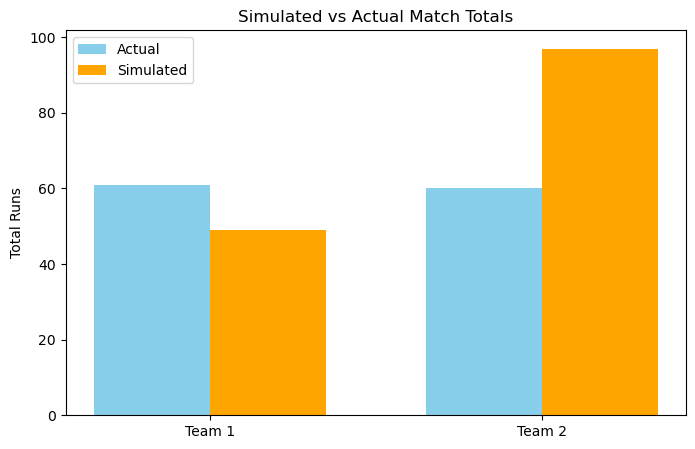

In [549]:
# Actual match totals
def get_actual_total(inning):
    total = 0
    for over in inning['overs']:
        for delivery in over['deliveries']:
            total += delivery['runs']['batter']
    return total

actual_team1_total = get_actual_total(match_example['innings'][0])
actual_team2_total = get_actual_total(match_example['innings'][1])

sim_team1_total = sim_result['team1']['total']
sim_team2_total = sim_result['team2']['total']

# Visualization
teams = ['Team 1', 'Team 2']
actual_totals = [actual_team1_total, actual_team2_total]
sim_totals = [sim_team1_total, sim_team2_total]

x = np.arange(len(teams))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, actual_totals, width, label='Actual', color='skyblue')
plt.bar(x + width/2, sim_totals, width, label='Simulated', color='orange')
plt.ylabel('Total Runs')
plt.title('Simulated vs Actual Match Totals')
plt.xticks(x, teams)
plt.legend()
plt.show()

In [551]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_match(team1_players, team2_players, n_simulations=1000):
    team1_totals = []
    team2_totals = []
    
    for _ in range(n_simulations):
        sim_result = simulate_match(team1_players, team2_players)
        team1_totals.append(sim_result['team1']['total'])
        team2_totals.append(sim_result['team2']['total'])
    
    # Compute averages
    avg_team1 = np.mean(team1_totals)
    avg_team2 = np.mean(team2_totals)
    
    return {
        "team1_totals": team1_totals,
        "team2_totals": team2_totals,
        "avg_team1": avg_team1,
        "avg_team2": avg_team2
    }

In [553]:
# Get players from innings as before
team1_players = get_players_from_inning(match_example['innings'][0])
team2_players = get_players_from_inning(match_example['innings'][1])

# Run Monte Carlo
mc_result = monte_carlo_match(team1_players, team2_players, n_simulations=1000)

# Actual totals
actual_team1_total = get_actual_total(match_example['innings'][0])
actual_team2_total = get_actual_total(match_example['innings'][1])

print("Actual totals:", actual_team1_total, actual_team2_total)
print("Monte Carlo averages:", mc_result['avg_team1'], mc_result['avg_team2'])

Actual totals: 61 60
Monte Carlo averages: 111.459 72.182


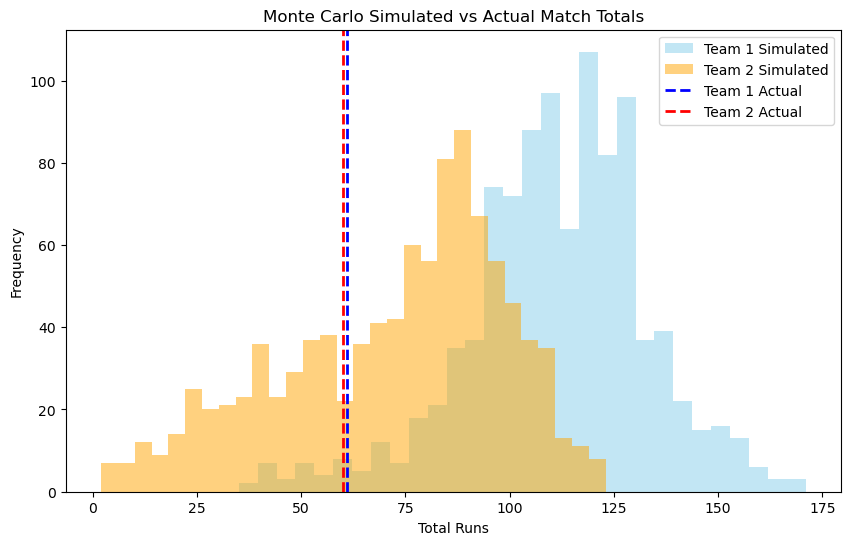

In [555]:
plt.figure(figsize=(10,6))

plt.hist(mc_result['team1_totals'], bins=30, alpha=0.5, label='Team 1 Simulated', color='skyblue')
plt.hist(mc_result['team2_totals'], bins=30, alpha=0.5, label='Team 2 Simulated', color='orange')

# Overlay actual totals
plt.axvline(actual_team1_total, color='blue', linestyle='dashed', linewidth=2, label='Team 1 Actual')
plt.axvline(actual_team2_total, color='red', linestyle='dashed', linewidth=2, label='Team 2 Actual')

plt.xlabel('Total Runs')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulated vs Actual Match Totals')
plt.legend()
plt.show()

In [559]:
correct_predictions = 0
total_matches = 0  # count only matches with 2 innings
n_simulations = 500

for match in test_matches:
    data = match['data']
    
    # Make sure the match has 2 innings
    if len(data['innings']) < 2:
        continue  # skip this match
    
    total_matches += 1
    
    # Extract batting orders (Assume batting order is as listed in dataset)
    team1_players = get_players_from_inning(data['innings'][0])
    team2_players = get_players_from_inning(data['innings'][1])
    
    # Actual totals
    actual_team1_total = get_actual_total(data['innings'][0])
    actual_team2_total = get_actual_total(data['innings'][1])
    
    actual_winner = 1 if actual_team1_total > actual_team2_total else 2
    
    # Monte Carlo simulations
    mc_result = monte_carlo_match(team1_players, team2_players, n_simulations=n_simulations)
    
    # Predicted winner
    team1_wins = sum([t1 > t2 for t1, t2 in zip(mc_result['team1_totals'], mc_result['team2_totals'])])
    team2_wins = n_simulations - team1_wins
    predicted_winner = 1 if team1_wins > team2_wins else 2
    
    if predicted_winner == actual_winner:
        correct_predictions += 1

accuracy = correct_predictions / total_matches
print(f"Predicted winner accuracy over {total_matches} test matches: {accuracy:.2%}")

Predicted winner accuracy over 991 test matches: 61.96%


In [561]:
import numpy as np

correct_predictions = 0
total_matches = 0
total_log_loss = 0

n_simulations = 500
eps = 1e-15   # prevents log(0)

for match in test_matches:
    data = match['data']
    
    # ensure match has two innings
    if len(data['innings']) < 2:
        continue

    total_matches += 1

    # extract players
    team1_players = get_players_from_inning(data['innings'][0])
    team2_players = get_players_from_inning(data['innings'][1])

    # actual totals
    actual_team1_total = get_actual_total(data['innings'][0])
    actual_team2_total = get_actual_total(data['innings'][1])

    # true outcome
    actual_winner = 1 if actual_team1_total > actual_team2_total else 2

    # run Monte Carlo simulation
    mc_result = monte_carlo_match(team1_players, team2_players, n_simulations=n_simulations)

    team1_totals = mc_result['team1_totals']
    team2_totals = mc_result['team2_totals']

    # count wins
    team1_wins = sum(t1 > t2 for t1, t2 in zip(team1_totals, team2_totals))
    team2_wins = n_simulations - team1_wins

    # predicted probabilities
    p_team1 = team1_wins / n_simulations
    p_team1 = np.clip(p_team1, eps, 1 - eps)

    # predicted winner (for accuracy)
    predicted_winner = 1 if p_team1 > 0.5 else 2

    if predicted_winner == actual_winner:
        correct_predictions += 1

    # encode true outcome
    y = 1 if actual_winner == 1 else 0

    # log-loss contribution
    loss = -(y * np.log(p_team1) + (1 - y) * np.log(1 - p_team1))
    total_log_loss += loss


# final metrics
accuracy = correct_predictions / total_matches
avg_log_loss = total_log_loss / total_matches

print(f"Total matches evaluated: {total_matches}")
print(f"Prediction accuracy: {accuracy:.2%}")
print(f"Log-loss: {avg_log_loss:.4f}")

Total matches evaluated: 991
Prediction accuracy: 60.95%
Log-loss: 0.6869
